In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 kB 1.5 MB/s eta 0:00:00
Processando: ES...
Processando: MG...
Processando: RJ...
Processando: SP...

Arquivo salvo em: /kaggle/working/mortalidade_hepatite_b_hiv_sudeste_2010_2024.csv


,UF,ANO,GRUPO,OBITOS
0,ES,2010,Hepatite B,18
1,ES,2010,HIV/AIDS,217
2,ES,2011,Hepatite B,17
3,ES,2011,HIV/AIDS,258
4,ES,2012,Hepatite B,6


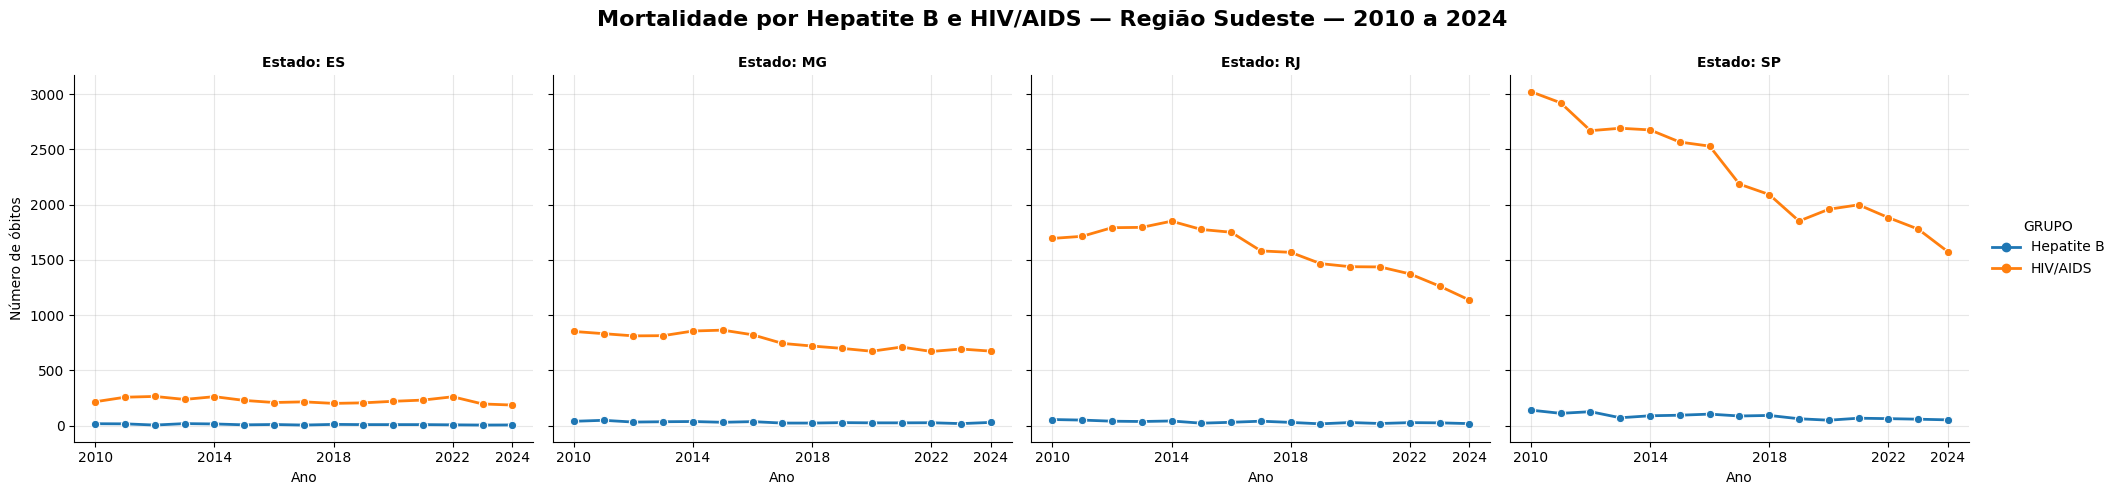

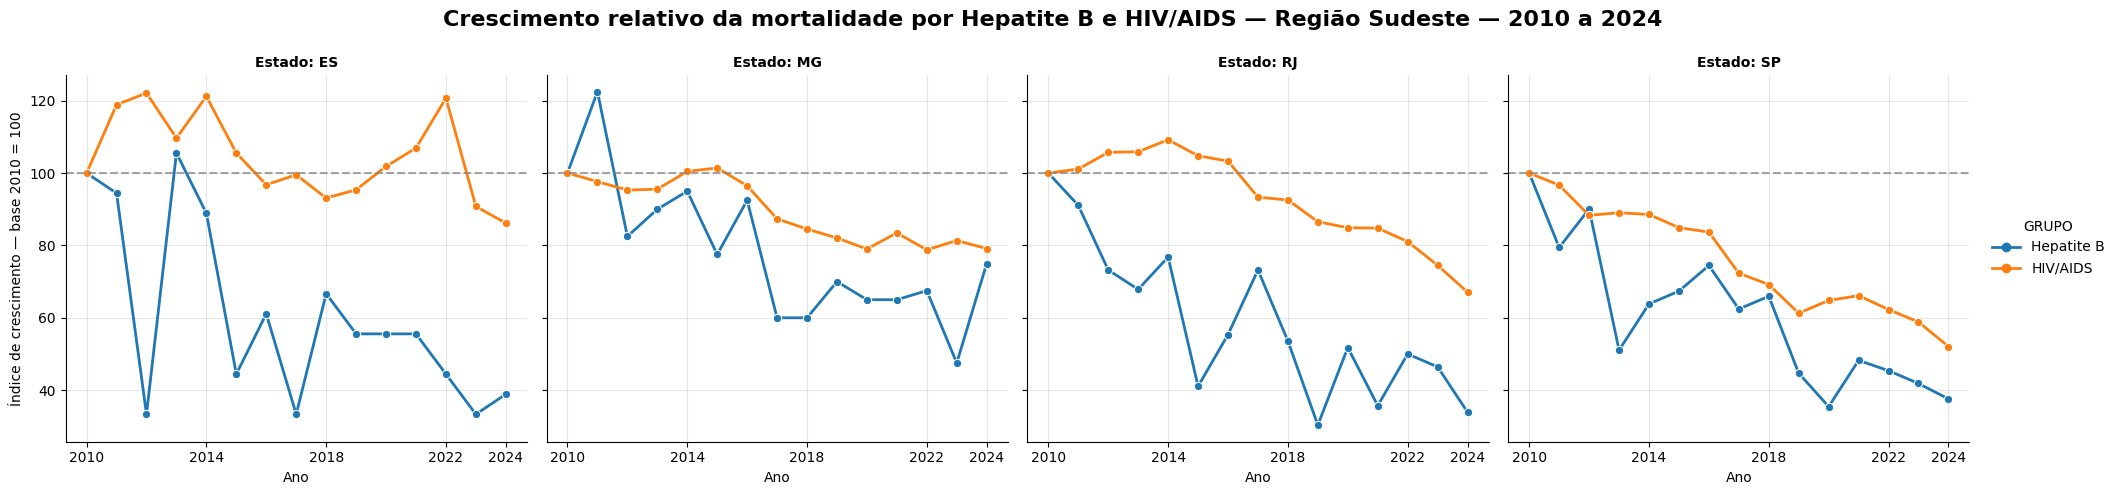


 RANKING — MORTALIDADE POR HEPATITE B E HIV/AIDS — REGIÃO Sudeste
 Comparação: 2010 vs 2024

-> Grupo: Hepatite B
   SP: 141 -> 53 óbitos (-62.4% em relação a 2010)
   MG: 40 -> 30 óbitos (-25.0% em relação a 2010)
   RJ: 56 -> 19 óbitos (-66.1% em relação a 2010)
   ES: 18 -> 7 óbitos (-61.1% em relação a 2010)

-> Grupo: HIV/AIDS
   SP: 3023 -> 1574 óbitos (-47.9% em relação a 2010)
   RJ: 1695 -> 1137 óbitos (-32.9% em relação a 2010)
   MG: 853 -> 675 óbitos (-20.9% em relação a 2010)
   ES: 217 -> 187 óbitos (-13.8% em relação a 2010)


In [2]:
# ============================================================
# 1. INSTALAÇÃO E IMPORTE DE BIBLIOTECAS
# ============================================================

!pip install pyreaddbc dbfread -q

import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from urllib.request import urlretrieve
from pyreaddbc import dbc2dbf
from dbfread import DBF

# ============================================================
# 2. CONFIGURAÇÕES DA REGIÃO
# ============================================================

REGIAO = "Sudeste"
SLUG_REGIAO = "sudeste"

ESTADOS = [
    "ES",
    "MG",
    "RJ",
    "SP"
]

ANOS = range(2010, 2025)

pasta_base = Path("/kaggle/working/dados_sus")
pasta_base.mkdir(exist_ok=True, parents=True)

# ============================================================
# 3. FUNÇÕES DE APOIO
# ============================================================

def baixar_arquivo(url, destino):
    if destino.exists():
        return True
    try:
        urlretrieve(url, destino)
        return True
    except Exception as e:
        print(f"Falha ao baixar {url}: {e}")
        return False


def ler_e_limpar_dbc(caminho_dbc):
    """Converte DBC para DBF, lê o DBF e apaga o DBF temporário."""
    caminho_dbf = caminho_dbc.with_suffix(".dbf")
    try:
        dbc2dbf(str(caminho_dbc), str(caminho_dbf))
        df = pd.DataFrame(iter(DBF(str(caminho_dbf), encoding="latin1")))

        if caminho_dbf.exists():
            os.remove(caminho_dbf)

        return df

    except Exception as e:
        print(f"Erro ao ler {caminho_dbc.name}: {e}")

        if caminho_dbf.exists():
            os.remove(caminho_dbf)

        return None


def limpar_cid(causa):
    """Padroniza CID-10 removendo ponto e espaços."""
    if pd.isna(causa):
        return ""
    return str(causa).upper().replace(".", "").strip()


def filtrar_causas(causa):
    """
    Classificação por CID-10 da causa básica de óbito.

    Hepatite B:
    B16   = hepatite aguda B
    B170  = infecção aguda Delta em portador de hepatite B
    B180  = hepatite viral crônica B com agente Delta
    B181  = hepatite crônica viral B sem agente Delta

    HIV/AIDS:
    B20-B24 = doença pelo vírus da imunodeficiência humana [HIV]

    Observação:
    Z21 não foi incluído porque representa infecção assintomática pelo HIV.
    """
    c = limpar_cid(causa)

    if (
        c.startswith("B16")
        or c.startswith("B170")
        or c.startswith("B180")
        or c.startswith("B181")
    ):
        return "Hepatite B"

    if any(c.startswith(cid) for cid in ["B20", "B21", "B22", "B23", "B24"]):
        return "HIV/AIDS"

    return "Outros"

# ============================================================
# 4. PROCESSAMENTO PRINCIPAL
# ============================================================

resultados = []

for uf in ESTADOS:
    print(f"Processando: {uf}...")

    for ano in ANOS:
        nome = f"DO{uf}{ano}.dbc"
        url = f"ftp://ftp.datasus.gov.br/dissemin/publicos/SIM/CID10/DORES/{nome}"
        caminho_dbc = pasta_base / nome

        if baixar_arquivo(url, caminho_dbc):
            df_temp = ler_e_limpar_dbc(caminho_dbc)

            if df_temp is not None and "CAUSABAS" in df_temp.columns:
                df_temp["GRUPO"] = df_temp["CAUSABAS"].apply(filtrar_causas)

                resumo = (
                    df_temp[df_temp["GRUPO"] != "Outros"]
                    .groupby("GRUPO")
                    .size()
                    .reset_index(name="OBITOS")
                )

                resumo["UF"] = uf
                resumo["ANO"] = ano

                resultados.append(resumo)

# ============================================================
# 5. CONSOLIDAÇÃO
# ============================================================

GRUPOS_ALVO = ["Hepatite B", "HIV/AIDS"]

if resultados:
    df_final = pd.concat(resultados, ignore_index=True)
else:
    df_final = pd.DataFrame(columns=["GRUPO", "OBITOS", "UF", "ANO"])

indice_completo = pd.MultiIndex.from_product(
    [ESTADOS, ANOS, GRUPOS_ALVO],
    names=["UF", "ANO", "GRUPO"]
)

df_f = (
    df_final
    .groupby(["UF", "ANO", "GRUPO"])["OBITOS"]
    .sum()
    .reindex(indice_completo, fill_value=0)
    .reset_index()
)

arquivo_saida = f"/kaggle/working/mortalidade_hepatite_b_hiv_{SLUG_REGIAO}_2010_2024.csv"
df_f.to_csv(arquivo_saida, index=False)

print(f"\nArquivo salvo em: {arquivo_saida}")
display(df_f.head())

# Salva também com nome específico da região
df_sudeste = df_f.copy()

# ============================================================
# 6. GRÁFICO 1 — ÓBITOS ABSOLUTOS
# ============================================================

g = sns.relplot(
    data=df_f,
    x="ANO",
    y="OBITOS",
    hue="GRUPO",
    col="UF",
    col_wrap=4,
    kind="line",
    marker="o",
    linewidth=2
)

g.set_titles("Estado: {col_name}", fontweight="bold")
g.set_axis_labels("Ano", "Número de óbitos")

for ax in g.axes.flat:
    ax.grid(True, alpha=0.3)
    ax.set_xticks([2010, 2014, 2018, 2022, 2024])

plt.subplots_adjust(top=0.85)

g.fig.suptitle(
    f"Mortalidade por Hepatite B e HIV/AIDS — Região {REGIAO} — 2010 a 2024",
    fontsize=16,
    fontweight="bold"
)

plt.show()

# ============================================================
# 7. ÍNDICE DE CRESCIMENTO — BASE 2010
# ============================================================

df_2010 = (
    df_f[df_f["ANO"] == 2010][["UF", "GRUPO", "OBITOS"]]
    .rename(columns={"OBITOS": "OBITOS_2010"})
)

df_ind = pd.merge(
    df_f,
    df_2010,
    on=["UF", "GRUPO"],
    how="left"
)

df_ind["INDICE_CRESCIMENTO"] = np.where(
    df_ind["OBITOS_2010"] > 0,
    (df_ind["OBITOS"] / df_ind["OBITOS_2010"]) * 100,
    np.nan
)

df_ind_validos = df_ind.dropna(subset=["INDICE_CRESCIMENTO"])

if not df_ind_validos.empty:
    g = sns.relplot(
        data=df_ind_validos,
        x="ANO",
        y="INDICE_CRESCIMENTO",
        hue="GRUPO",
        col="UF",
        col_wrap=4,
        kind="line",
        marker="o",
        linewidth=2
    )

    g.set_titles("Estado: {col_name}", fontweight="bold")
    g.set_axis_labels("Ano", "Índice de crescimento — base 2010 = 100")

    for ax in g.axes.flat:
        ax.axhline(100, color="gray", linestyle="--", alpha=0.7)
        ax.grid(True, alpha=0.3)
        ax.set_xticks([2010, 2014, 2018, 2022, 2024])

    plt.subplots_adjust(top=0.85)

    g.fig.suptitle(
        f"Crescimento relativo da mortalidade por Hepatite B e HIV/AIDS — Região {REGIAO} — 2010 a 2024",
        fontsize=16,
        fontweight="bold"
    )

    plt.show()

else:
    print("\nNão foi possível calcular índice de crescimento porque todos os valores de 2010 foram zero.")

# ============================================================
# 8. RANKING 2010 vs 2024
# ============================================================

print("\n" + "=" * 80)
print(f" RANKING — MORTALIDADE POR HEPATITE B E HIV/AIDS — REGIÃO {REGIAO}")
print(" Comparação: 2010 vs 2024")
print("=" * 80)

df_2024 = df_ind[df_ind["ANO"] == 2024].copy()

for grupo in GRUPOS_ALVO:
    print(f"\n-> Grupo: {grupo}")

    df_g = df_2024[df_2024["GRUPO"] == grupo].copy()

    if df_g.empty:
        print("   Sem dados para o ano de 2024.")
        continue

    df_g["VARIACAO_ABSOLUTA"] = df_g["OBITOS"] - df_g["OBITOS_2010"]

    df_g = df_g.sort_values(
        by=["OBITOS", "VARIACAO_ABSOLUTA"],
        ascending=[False, False]
    )

    for _, row in df_g.iterrows():
        obitos_2010 = int(row["OBITOS_2010"]) if pd.notna(row["OBITOS_2010"]) else 0
        obitos_2024 = int(row["OBITOS"]) if pd.notna(row["OBITOS"]) else 0

        if obitos_2010 > 0:
            variacao_perc = ((obitos_2024 / obitos_2010) - 1) * 100

            print(
                f"   {row['UF']}: {obitos_2010} -> {obitos_2024} óbitos "
                f"({variacao_perc:+.1f}% em relação a 2010)"
            )

        else:
            print(
                f"   {row['UF']}: {obitos_2010} -> {obitos_2024} óbitos "
                f"(sem cálculo percentual porque 2010 = 0)"
            )